# Ornstein-Uhlenbeck Process

**What this is:** The Ornstein-Uhlenbeck process is mean reverting, which means its
drift pulls the level back toward a long run mean at a rate set by $\kappa$ rather than
wandering freely the way Brownian motion does.

**Why it matters:** Due to that reversion, it is typically the wrong model for an equity
price and the right one for quantities that have an equilibrium level, i.e. short rates
(Vasicek), commodity spot prices, and the spread in a pairs trade. The second half of
this notebook adds a seasonal mean, which is how the process is usually applied in energy
and agricultural markets.

## Setup

**Reproducibility:** this notebook is seeded, so re-running it reproduces the figures
exactly. A seed fixes the sample rather than the conclusion, so any claim made here
should hold across seeds rather than only at this one. Note also that NumPy guarantees
the `default_rng` stream for a given version rather than indefinitely, which is part of
why `requirements.txt` is pinned.

In [1]:
from __future__ import annotations

from collections.abc import Callable

import numpy as np
import numpy.typing as npt
import matplotlib.pyplot as plt

Array = npt.NDArray[np.float64]
RNG = int | np.random.Generator | None

plt.style.use('seaborn-v0_8')

## Parameters

| Symbol | Code | Meaning |
|---|---|---|
| $S_0$ | `S0` | level at time zero |
| $\kappa$ | `kappa` | mean reversion speed, higher means faster |
| $\theta$ | `theta` | long run mean level |
| $\sigma$ | `sigma` | volatility |
| $T$ | `T` | time horizon in years |
| $n$ | `n` | number of time steps (252 trading days) |
| $\Delta t$ | `dt` | time step size, $\Delta t = T/n$ |
| $\varepsilon_{i,j}$ | `epsilon` | independent standard normal shocks, $\varepsilon_{i,j} \sim \mathcal{N}(0,1)$ |

In [2]:
SEED = 20260913

num_paths = 100
n = 252
T = 1
dt = T/n
S0 = 1
theta = 1
sigma = 0.2
kappa = 3

## Model: Standard Ornstein-Uhlenbeck

**Continuous time:**

$$dS_t = \kappa \left( \theta - S_t \right) dt + \sigma \, dW_t$$

The drift is proportional to the distance from $\theta$, so the process is pulled back
toward its long run mean at a rate set by $\kappa$ rather than wandering freely. Unlike
geometric Brownian motion it is not restricted to positive values, which is appropriate
for a spread or a short rate but not for an equity price.

**Euler-Maruyama discretisation:**

$$S_{i+1,j} = S_{i,j} + \kappa \left( \theta - S_{i,j} \right) \Delta t
+ \sigma \sqrt{\Delta t} \, \varepsilon_{i,j}$$

where $i$ indexes time and $j$ indexes paths, with $i \in [0, n-1]$ and
$j \in [1, \texttt{num\_paths}]$.

It is worth noting that an exact transition density exists for this process, since
$S_{t+\Delta t}$ given $S_t$ is Gaussian with a known mean and variance. Euler is used
here because it generalises directly to the seasonal variant below, where $\theta$ becomes
time dependent.

**In code:** the loop steps `S[i + 1]` from `S[i]` directly, with `S` stored as
`(n + 1, num_paths)` so the array indexing matches the $(i, j)$ ordering above.

In [3]:
def simulate_ou(S0: float, kappa: float, theta: float | Callable[[int], float],
                sigma: float, n: int, dt: float, num_paths: int,
                rng: RNG = None) -> Array:
  """Ornstein-Uhlenbeck paths, shape (n+1, num_paths).

  theta may be a constant or a callable of the step index, which is what lets the
  seasonal variant below reuse this function rather than duplicating the loop.
  An exact transition density exists for constant theta, but Euler is used here
  because it generalises directly to the time-dependent case.

  Returns shape (n+1, num_paths), time along the first axis.
  """
  rng = np.random.default_rng(rng)
  theta_t = theta if callable(theta) else (lambda i: theta)
  epsilon = rng.normal(0,1,(n,num_paths))

  S = np.zeros((n+1,num_paths)); S[0,:] = S0
  for i in range(0,n):
    S[i+1] = S[i] + kappa * (theta_t(i) - S[i]) * dt + sigma * np.sqrt(dt) * epsilon[i]

  return S

S = simulate_ou(S0, kappa, theta, sigma, n, dt, num_paths, rng=SEED)

## Results: Standard Ornstein-Uhlenbeck

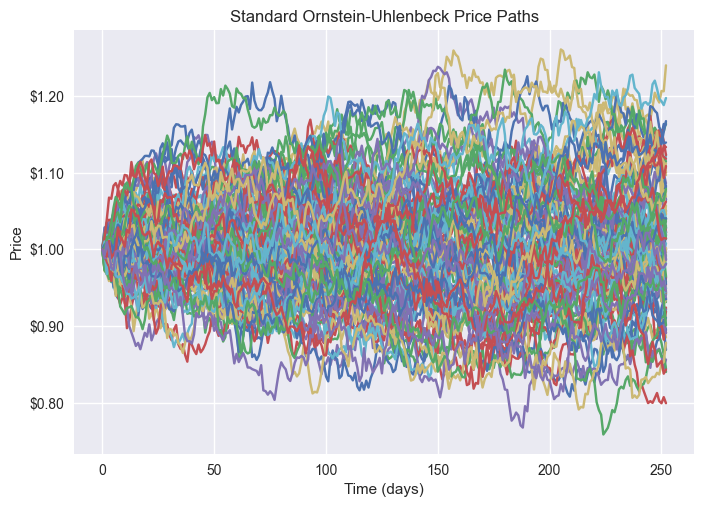

In [4]:
plt.plot(S)
plt.grid(True)
plt.xlabel("Time (days)")
plt.ylabel("Price")
plt.title("Standard Ornstein-Uhlenbeck Price Paths")
plt.gca().yaxis.set_major_formatter("${x:,.2f}")
plt.show()

## Parameters: seasonal variant

The seasonal variant replaces the constant long run mean with a deterministic function of
time, so that the level the process reverts to oscillates once over the horizon:

$$\theta_i = a + b \cos\!\left( \frac{2\pi \left( i - \frac{n}{2} \right)}{n} \right)$$

| Symbol | Code | Meaning |
|---|---|---|
| $a$ | `S0` | base mean level, reused from the starting price |
| $b$ | `0.5` | seasonal amplitude |
| $\sigma$ | `sigma_seasonal` | volatility, raised from $0.2$ to $0.4$ for this run |

Both runs are driven from the same seed, so they see identical shocks and the
difference between the plots comes from the model rather than from sampling noise. Note that $\sigma$ is also changed here, so the
comparison is not a clean isolation of the seasonal term on its own.

In [5]:
sigma_seasonal = 0.4
theta_seasonal = lambda i: S0 + 0.5 * np.cos(2 * np.pi / n * (i - n//2))

## Model: Seasonal Ornstein-Uhlenbeck

**Continuous time:**

$$dS_t = \kappa \left( \theta_t - S_t \right) dt + \sigma \, dW_t,
\qquad \theta_t = a + b \cos\!\left( \frac{2\pi \left( t - \frac{T}{2} \right)}{T} \right)$$

Making $\theta$ a function of time is how the process is usually applied to energy and
agricultural markets, where the equilibrium level itself moves with the season while the
reversion speed stays roughly constant.

**Euler-Maruyama discretisation:**

$$S_{i+1,j} = S_{i,j} + \kappa \left( \theta_i - S_{i,j} \right) \Delta t
+ \sigma \sqrt{\Delta t} \, \varepsilon_{i,j}$$

where $i$ indexes time and $j$ indexes paths, with $i \in [0, n-1]$ and
$j \in [1, \texttt{num\_paths}]$.

**In code:** `theta` becomes a lambda of the step index rather than a constant, evaluated
as `theta(i)` inside the same loop structure used above.

In [6]:
S_seasonal = simulate_ou(S0, kappa, theta_seasonal, sigma_seasonal, n, dt, num_paths, rng=SEED)

## Results: Seasonal Ornstein-Uhlenbeck

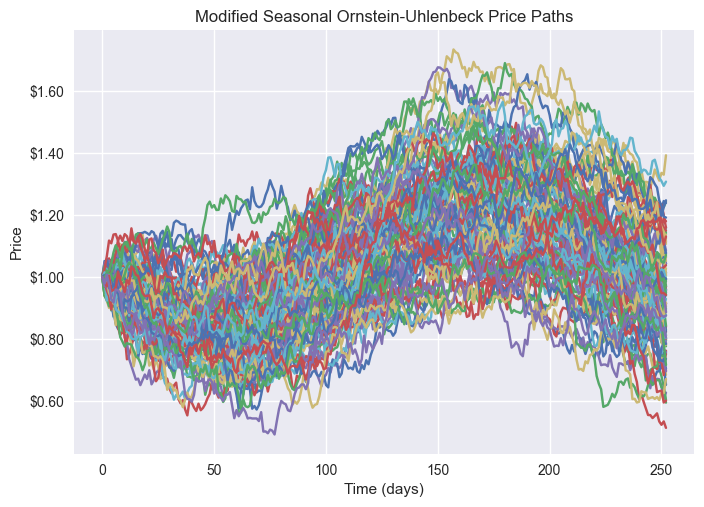

In [7]:
plt.plot(S_seasonal)
plt.grid(True)
plt.xlabel("Time (days)")
plt.ylabel("Price")
plt.title("Modified Seasonal Ornstein-Uhlenbeck Price Paths")
plt.gca().yaxis.set_major_formatter("${x:,.2f}")
plt.show()